# Spectral Calibration Framework

This notebook implements the common-field spectral calibration framework described in `docs/main.tex`.

**System boundary**
- Domain/core: latent-spectrum estimation, smooth gain/noise recovery, deployment correction, and consensus fusion.
- Application/orchestration: dataset loading, deterministic hold-out validation, plotting, and summary tables.
- Side effects: reading CSV files and rendering figures only.
- Pattern choice: the notebook stays thin and delegates the reusable estimation logic to `measurement_calibration.spectral_calibration`, which keeps the numerical core testable.

**Pragmatic simplifications kept explicit**
- The sensor update uses a nonnegative affine fit `Y = G S + N` at each frequency.
- Frequency smoothness is enforced with second-difference Tikhonov regularization, matching the penalized objective in the document.
- Sensor 7 is a soft anchor through regularization and a mild reliability weight boost, never a hard perfect-reference constraint.

In [26]:
from __future__ import annotations

import importlib
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def resolve_repo_root() -> Path:
    """Return the repository root regardless of the notebook launch directory."""

    candidates = [Path.cwd().resolve(), Path.cwd().resolve().parent]
    for candidate in candidates:
        if (candidate / "measurement_calibration").exists() and (
            candidate / "data"
        ).exists():
            return candidate
    raise RuntimeError(
        "Could not locate the repository root from the current notebook session"
    )


REPO_ROOT = resolve_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# Reload the local calibration module so rerunning this cell picks up
# edited function signatures without requiring a kernel restart.
import measurement_calibration.spectral_calibration as spectral_calibration_module

spectral_calibration_module = importlib.reload(spectral_calibration_module)
apply_deployed_calibration = spectral_calibration_module.apply_deployed_calibration
compute_network_consensus = spectral_calibration_module.compute_network_consensus
fit_spectral_calibration = spectral_calibration_module.fit_spectral_calibration
load_calibration_dataset = spectral_calibration_module.load_calibration_dataset
make_holdout_split = spectral_calibration_module.make_holdout_split
power_linear_to_db = spectral_calibration_module.power_linear_to_db

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:.3f}".format

DATA_ROOT = REPO_ROOT / "data"
AQUISITION_DIR = DATA_ROOT / "aquisitions"
RESPONSE_DIR = DATA_ROOT / "frequency-responses"
EXCLUDED_SENSOR_IDS = (
    "Node3-Bogota",
    "Node6-Bogota",
    "Node8-Bogota",
    "Node9-Funza",
)


## Load And Align The Common-Field Dataset

This analysis keeps only the nodes that satisfy the common-field assumptions in Bogota.

- `Node3-Bogota`, `Node6-Bogota`, and `Node8-Bogota` are excluded because their measurements do not meet the required calibration conditions.
- `Node9-Funza` is excluded because it was deployed in Funza rather than Bogota.
- `Node10-Bogota` still starts one experiment later than the main sequence, so alignment must handle a small integer shift.

After those exclusions, the loader keeps only the band shared by the retained sensors and uses small integer index shifts relative to `Node7-Bogota` to build the admissible calibration tensor required by the model assumptions.


In [27]:
dataset = load_calibration_dataset(
    acquisition_dir=AQUISITION_DIR,
    response_dir=RESPONSE_DIR,
    reference_sensor_id="Node7-Bogota",
    excluded_sensor_ids=EXCLUDED_SENSOR_IDS,
)

alignment_summary = pd.DataFrame(
    {
        "sensor_id": dataset.sensor_ids,
        "shift_vs_node7": [
            dataset.sensor_shifts[sensor_id] for sensor_id in dataset.sensor_ids
        ],
        "median_alignment_error_ms": [
            dataset.alignment_median_error_ms[sensor_id]
            for sensor_id in dataset.sensor_ids
        ],
        "selected_rows": [
            int(dataset.source_row_indices[sensor_id].size)
            for sensor_id in dataset.sensor_ids
        ],
        "nominal_gain_center_db": power_linear_to_db(
            dataset.nominal_gain_power[:, dataset.nominal_gain_power.shape[1] // 2]
        ),
    }
)

display(alignment_summary)
print(f"Excluded sensors: {', ' .join(EXCLUDED_SENSOR_IDS)}")
print(
    f"Selected common band: {dataset.selected_band_hz[0] / 1e6:.1f}-{dataset.selected_band_hz[1] / 1e6:.1f} MHz"
)
print(
    f"Observation tensor shape: {dataset.observations_power.shape} = (sensors, experiments, frequencies)"
)
print(
    f"Frequency resolution: {(dataset.frequency_hz[1] - dataset.frequency_hz[0]):.3f} Hz per bin"
)


,sensor_id,shift_vs_node7,median_alignment_error_ms,selected_rows,nominal_gain_center_db
0,Node1-Bogota,0,2029.000,104,-3.117
1,Node10-Bogota,-1,356.500,104,2.616
2,Node2-Bogota,0,1982.000,104,4.761
3,Node4-Bogota,0,227.000,104,-6.860
4,Node5-Bogota,0,414.000,104,-1.577
5,Node7-Bogota,0,0.000,104,4.177


Excluded sensors: Node3-Bogota, Node6-Bogota, Node8-Bogota, Node9-Funza
Selected common band: 88.0-108.0 MHz
Observation tensor shape: (6, 104, 32768) = (sensors, experiments, frequencies)
Frequency resolution: 610.352 Hz per bin


## Fit The Alternating Latent-Variable Model

We keep the final 20% of aligned experiments as a strict hold-out set, which mirrors the validation principle in `docs/main.tex`: parameters are estimated on common-field training experiments and evaluated on unseen common-field experiments after deployment-time correction.

The fitting cell below uses the nominal response curves as multiplicative baselines, then estimates a smooth residual correction around them.

In [28]:
train_indices, test_indices = make_holdout_split(
    n_experiments=dataset.observations_power.shape[1],
    test_fraction=0.2,
)

fit_config = {
    "n_iterations": 8,
    "lambda_gain_smooth": 50.0,
    "lambda_noise_smooth": 20.0,
    "lambda_reliable_anchor": 0.5,
    "reliable_weight_boost": 1.10,
}

start_time = time.perf_counter()
result = fit_spectral_calibration(
    observations_power=dataset.observations_power,
    frequency_hz=dataset.frequency_hz,
    sensor_ids=dataset.sensor_ids,
    nominal_gain_power=dataset.nominal_gain_power,
    train_indices=train_indices,
    test_indices=test_indices,
    reliable_sensor_id="Node7-Bogota",
    **fit_config,
)
fit_duration_s = time.perf_counter() - start_time

fit_summary = pd.DataFrame(
    {
        "parameter": [
            "train_experiments",
            "test_experiments",
            "iterations",
            "fit_duration_s",
            "objective_start",
            "objective_end",
        ],
        "value": [
            int(train_indices.size),
            int(test_indices.size),
            fit_config["n_iterations"],
            fit_duration_s,
            float(result.objective_history[0]),
            float(result.objective_history[-1]),
        ],
    }
)

display(fit_summary)

,parameter,value
0,train_experiments,83.000
1,test_experiments,21.000
2,iterations,8.000
3,fit_duration_s,14.893
4,objective_start,-105986119.603
5,objective_end,-110374348.933


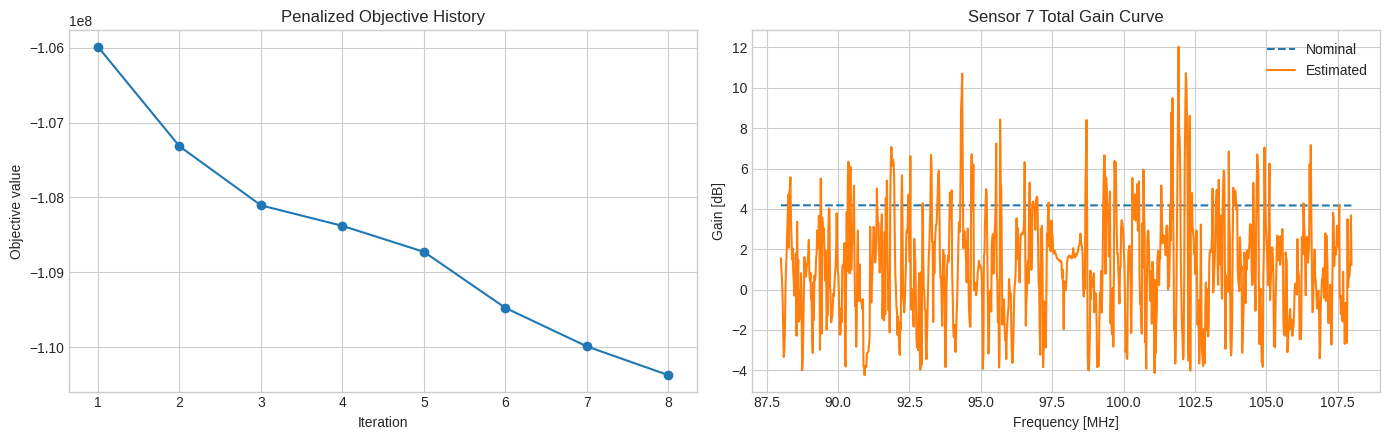

In [29]:
plot_stride = max(1, dataset.frequency_hz.size // 1024)
freq_mhz = dataset.frequency_hz[::plot_stride] / 1e6

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(
    np.arange(1, result.objective_history.size + 1),
    result.objective_history,
    marker="o",
)
axes[0].set_title("Penalized Objective History")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Objective value")

reliable_sensor_index = dataset.sensor_ids.index("Node7-Bogota")
axes[1].plot(
    freq_mhz,
    power_linear_to_db(result.nominal_gain_power[reliable_sensor_index, ::plot_stride]),
    linestyle="--",
    label="Nominal",
)
axes[1].plot(
    freq_mhz,
    power_linear_to_db(result.gain_power[reliable_sensor_index, ::plot_stride]),
    label="Estimated",
)
axes[1].set_title("Sensor 7 Total Gain Curve")
axes[1].set_xlabel("Frequency [MHz]")
axes[1].set_ylabel("Gain [dB]")
axes[1].legend()
plt.tight_layout()

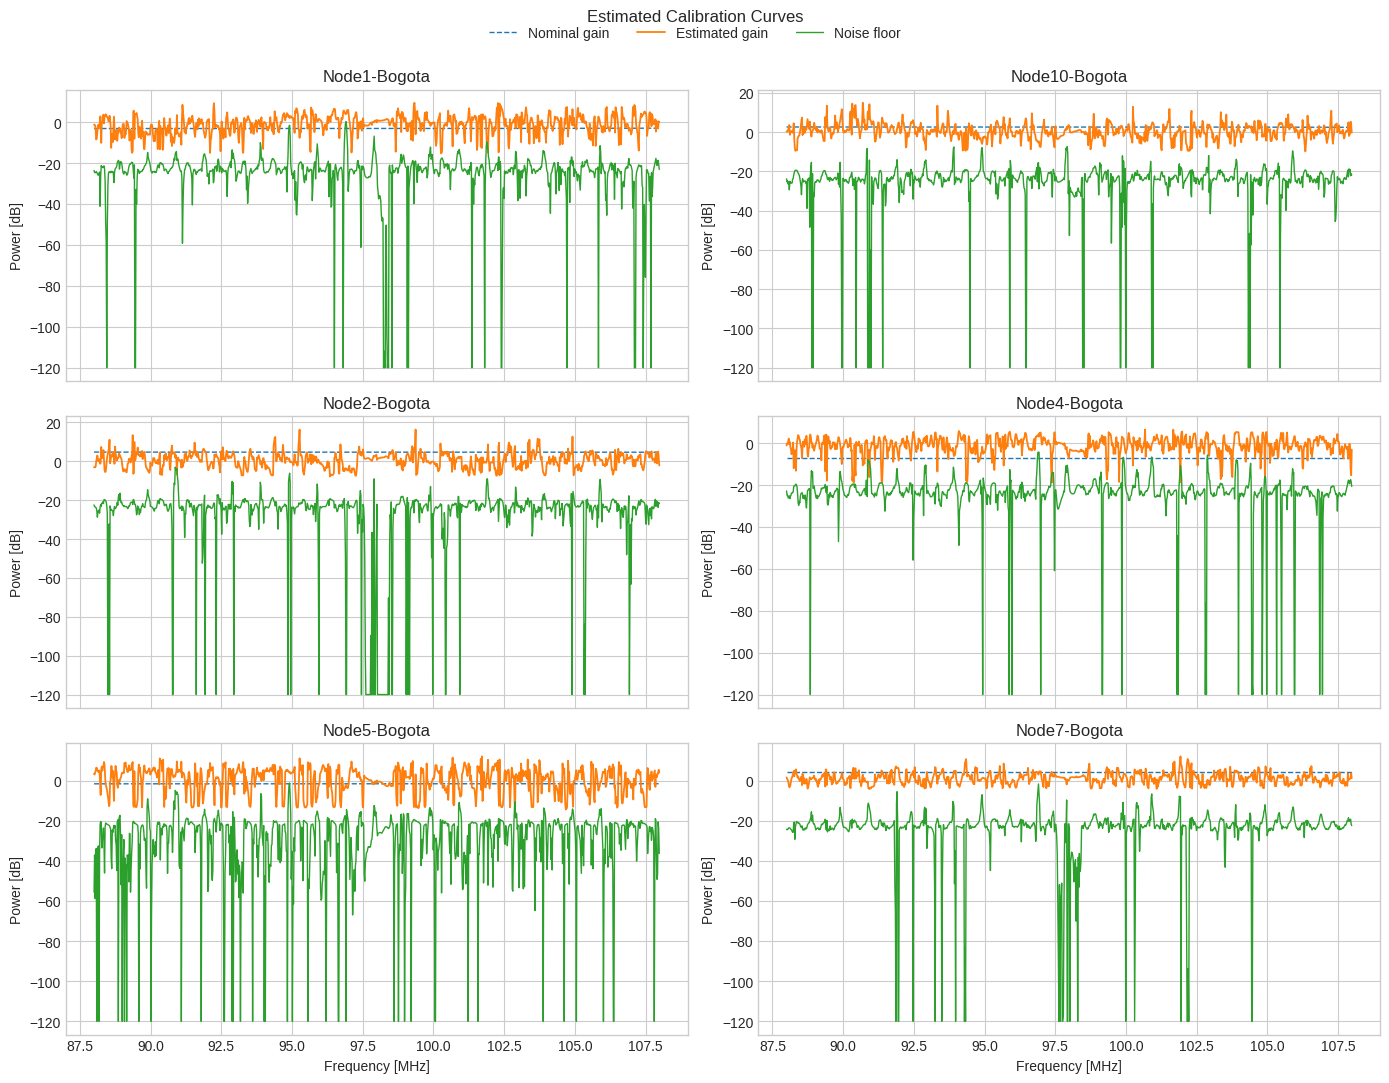

In [30]:
estimated_gain_db = power_linear_to_db(result.gain_power[:, ::plot_stride])
nominal_gain_db = power_linear_to_db(result.nominal_gain_power[:, ::plot_stride])
noise_floor_db = power_linear_to_db(
    np.clip(result.additive_noise_power[:, ::plot_stride], 1e-18, None)
)

n_sensors = len(dataset.sensor_ids)
n_cols = 2
n_rows = int(np.ceil(n_sensors / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 3.6 * n_rows),
    sharex=True,
    squeeze=False,
)
for axis, sensor_id, nominal_db, estimated_db, noise_db in zip(
    axes.flat,
    dataset.sensor_ids,
    nominal_gain_db,
    estimated_gain_db,
    noise_floor_db,
):
    axis.plot(freq_mhz, nominal_db, linestyle="--", linewidth=1.0, label="Nominal gain")
    axis.plot(freq_mhz, estimated_db, linewidth=1.3, label="Estimated gain")
    axis.plot(freq_mhz, noise_db, linewidth=1.0, label="Noise floor")
    axis.set_title(sensor_id)
    axis.set_ylabel("Power [dB]")

for axis in axes.flat[n_sensors:]:
    axis.set_visible(False)

for axis in axes[-1, :]:
    if axis.get_visible():
        axis.set_xlabel("Frequency [MHz]")

legend_axis = axes.flat[0]
handles, labels = legend_axis.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 0.995))
fig.suptitle("Estimated Calibration Curves", y=0.999)
fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.985))


## Hold-Out Validation

The validation target is not simply a lower training loss. We check whether the fitted sensor-specific correction reduces inter-sensor disagreement on held-out common-field experiments.

Two diagnostics are reported:

1. The average across-sensor dispersion in dB before and after calibration.
2. Sensor-specific residual bias and RMSE with respect to the weighted network consensus after correction.

A successful calibration should reduce these dispersion metrics. If it does not, the notebook is still doing useful work: it is telling us that the current common-field assumption, nominal-response scaling, or regularization settings are not yet consistent with the observed data.

In [31]:
raw_test_power = dataset.observations_power[:, result.test_indices, :]
corrected_test_power = apply_deployed_calibration(
    observations_power=raw_test_power,
    gain_power=result.gain_power,
    additive_noise_power=result.additive_noise_power,
)
consensus_test_power = compute_network_consensus(
    corrected_power=corrected_test_power,
    residual_variance_power2=result.residual_variance_power2,
)

raw_test_db = power_linear_to_db(raw_test_power)
corrected_test_db = power_linear_to_db(corrected_test_power)
consensus_test_db = power_linear_to_db(consensus_test_power)

raw_dispersion_db = np.std(raw_test_db, axis=0)
corrected_dispersion_db = np.std(corrected_test_db, axis=0)
corrected_residual_db = corrected_test_db - consensus_test_db[np.newaxis, :, :]
dispersion_ratio = float(np.mean(corrected_dispersion_db) / np.mean(raw_dispersion_db))

validation_metrics = pd.DataFrame(
    {
        "metric": [
            "mean_raw_sensor_std_db",
            "mean_corrected_sensor_std_db",
            "median_raw_sensor_std_db",
            "median_corrected_sensor_std_db",
            "corrected_to_raw_dispersion_ratio",
        ],
        "value": [
            float(np.mean(raw_dispersion_db)),
            float(np.mean(corrected_dispersion_db)),
            float(np.median(raw_dispersion_db)),
            float(np.median(corrected_dispersion_db)),
            dispersion_ratio,
        ],
    }
)

sensor_validation = pd.DataFrame(
    {
        "sensor_id": dataset.sensor_ids,
        "mean_bias_to_consensus_db": np.mean(corrected_residual_db, axis=(1, 2)),
        "rmse_to_consensus_db": np.sqrt(np.mean(corrected_residual_db**2, axis=(1, 2))),
        "mean_residual_sigma2": np.mean(result.residual_variance_power2, axis=1),
    }
).sort_values("rmse_to_consensus_db")

if dispersion_ratio < 1.0:
    print(
        f"Hold-out validation improved: corrected dispersion is {dispersion_ratio:.3f}x the raw dispersion."
    )
else:
    print(
        "Hold-out validation did not improve yet: "
        f"corrected dispersion is {dispersion_ratio:.3f}x the raw dispersion. "
        "This suggests revisiting the common-field assumptions, the nominal-response scaling, or the regularization strength."
    )

display(validation_metrics)
display(sensor_validation)

Hold-out validation did not improve yet: corrected dispersion is 9.270x the raw dispersion. This suggests revisiting the common-field assumptions, the nominal-response scaling, or the regularization strength.


,metric,value
0,mean_raw_sensor_std_db,0.917
1,mean_corrected_sensor_std_db,8.496
2,median_raw_sensor_std_db,0.596
3,median_corrected_sensor_std_db,1.641
4,corrected_to_raw_dispersion_ratio,9.270


,sensor_id,mean_bias_to_consensus_db,rmse_to_consensus_db,mean_residual_sigma2
1,Node10-Bogota,-2.495,14.771,0.003
4,Node5-Bogota,-1.381,15.261,0.004
5,Node7-Bogota,-4.638,16.896,0.003
3,Node4-Bogota,-4.748,20.533,0.003
2,Node2-Bogota,-6.762,22.881,0.003
0,Node1-Bogota,-6.455,23.459,0.003


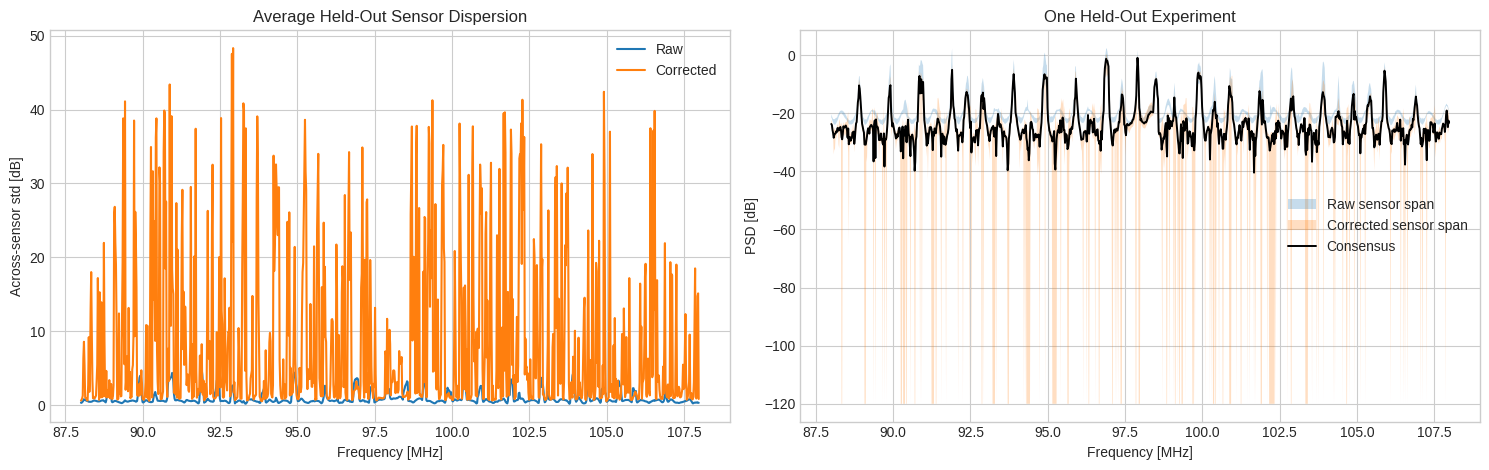

In [32]:
mean_raw_dispersion_profile_db = np.mean(raw_dispersion_db, axis=0)
mean_corrected_dispersion_profile_db = np.mean(corrected_dispersion_db, axis=0)
held_out_experiment = 0

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
axes[0].plot(freq_mhz, mean_raw_dispersion_profile_db[::plot_stride], label="Raw")
axes[0].plot(
    freq_mhz, mean_corrected_dispersion_profile_db[::plot_stride], label="Corrected"
)
axes[0].set_title("Average Held-Out Sensor Dispersion")
axes[0].set_xlabel("Frequency [MHz]")
axes[0].set_ylabel("Across-sensor std [dB]")
axes[0].legend()

axes[1].fill_between(
    freq_mhz,
    np.min(raw_test_db[:, held_out_experiment, :], axis=0)[::plot_stride],
    np.max(raw_test_db[:, held_out_experiment, :], axis=0)[::plot_stride],
    alpha=0.25,
    label="Raw sensor span",
)
axes[1].fill_between(
    freq_mhz,
    np.min(corrected_test_db[:, held_out_experiment, :], axis=0)[::plot_stride],
    np.max(corrected_test_db[:, held_out_experiment, :], axis=0)[::plot_stride],
    alpha=0.25,
    label="Corrected sensor span",
)
axes[1].plot(
    freq_mhz,
    consensus_test_db[held_out_experiment, ::plot_stride],
    color="black",
    linewidth=1.4,
    label="Consensus",
)
axes[1].set_title("One Held-Out Experiment")
axes[1].set_xlabel("Frequency [MHz]")
axes[1].set_ylabel("PSD [dB]")
axes[1].legend()
plt.tight_layout()

## Deployment Interpretation

Once the gain and additive-noise curves have been estimated, any new sensor PSD can be transferred to the common network scale with

`S_hat = max(0, (Y - N) / G)`.

When the deployed sensors are again observing the same field, the corrected spectra can be fused with a variance-weighted consensus. The helper functions below are the same ones used in the validation cells above.

In [33]:
deployment_example = {
    "gain_shape": result.gain_power.shape,
    "noise_shape": result.additive_noise_power.shape,
    "consensus_shape": consensus_test_power.shape,
    "first_test_timestamp_ms": int(
        dataset.experiment_timestamps_ms[result.test_indices[0]]
    ),
}
deployment_example

{'gain_shape': (6, 32768),
 'noise_shape': (6, 32768),
 'consensus_shape': (21, 32768),
 'first_test_timestamp_ms': 1771939100210}